# VSD Lower-Limb Knee Cropping Pipeline

This notebook extracts individual knee volumes from bilateral VSD lower-limb CT scans.

**Pipeline stages:**
1. Data discovery & filtering (exclude subject 010)
2. Knee region identification via bone cross-section profile
3. Bilateral leg separation using connected-component analysis
4. Crop ±100mm around knee center per leg
5. Save individual knee volumes as NIfTI

**Input**: Raw DICOM lower-limb CT volumes from `data/raw/VSD_Dataset/`  
**Output**: Cropped knee NIfTI volumes in `data/raw/healthy/`

**Confirmed parameters:**
- Knee crop margin: ±100mm around identified knee center
- Leg separation: Connected-component analysis on axial bone mask
- Excluded: Subject 010 (scan too short, does not contain knee region)

## Cell 1 — Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d, label as ndimage_label, generate_binary_structure
from scipy.signal import find_peaks

# ============================================================
# Configuration
# ============================================================
PROJECT_ROOT = Path(r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")

# Raw VSD data
VSD_ROOT = PROJECT_ROOT / "data" / "raw" / "VSD_Dataset"

# Output directory for cropped knee volumes
OUTPUT_DIR = PROJECT_ROOT / "data" / "raw" / "healthy"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Subjects to exclude (confirmed: 010 scan too short, no knee region)
EXCLUDE_SUBJECTS = {"010"}

# Knee identification
BONE_HU_THRESHOLD = 200       # HU threshold for bone detection
KNEE_CROP_MARGIN_MM = 100.0   # ±100mm around knee center

# Bone profile smoothing
PROFILE_SMOOTH_SIGMA = 20     # Gaussian smoothing for bone area profile
PEAK_MIN_HEIGHT_FRAC = 0.2    # Minimum peak height as fraction of max
PEAK_MIN_DISTANCE = 80        # Minimum distance between peaks (slices)

print("Configuration loaded.")
print(f"  VSD root   : {VSD_ROOT}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Excluded   : {EXCLUDE_SUBJECTS}")
print(f"  Crop margin: ±{KNEE_CROP_MARGIN_MM}mm")

Configuration loaded.
  VSD root   : c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\VSD_Dataset
  Output dir : c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy
  Excluded   : {'010'}
  Crop margin: ±100.0mm


## Cell 2 — Data Discovery

Scan VSD directory for subjects. Each subject has a subfolder named `SMIR.Lower_limb.{Age}Y.{Sex}.CT.{ID}` containing DICOM files.

In [2]:
def discover_vsd_cases(vsd_root, exclude=None):
    """Discover VSD subject folders and extract metadata."""
    exclude = exclude or set()
    cases = []

    for subject_name in sorted(os.listdir(vsd_root)):
        subject_dir = vsd_root / subject_name
        if not subject_dir.is_dir():
            continue

        if subject_name in exclude:
            print(f"  [SKIP] {subject_name} (excluded)")
            continue

        # Find the SMIR subfolder containing DICOMs
        subdirs = [d for d in subject_dir.iterdir() if d.is_dir()]
        if not subdirs:
            print(f"  [SKIP] {subject_name}: no subdirectory")
            continue

        smir_dir = subdirs[0]
        smir_name = smir_dir.name

        # Parse demographics from folder name: SMIR.Lower_limb.{Age}Y.{Sex}.CT.{ID}
        parts = smir_name.split(".")
        age = parts[2] if len(parts) > 2 else "?"
        sex = parts[3] if len(parts) > 3 else "?"

        # Load DICOM and extract metadata
        reader = sitk.ImageSeriesReader()
        dicom_names = reader.GetGDCMSeriesFileNames(str(smir_dir))
        if not dicom_names:
            print(f"  [SKIP] {subject_name}: no DICOM files")
            continue

        reader.SetFileNames(dicom_names)
        img = reader.Execute()

        cases.append({
            "subject_id": subject_name,
            "smir_name": smir_name,
            "age": age,
            "sex": sex,
            "dicom_dir": str(smir_dir),
            "size_xyz": img.GetSize(),
            "spacing_xyz": tuple(round(s, 6) for s in img.GetSpacing()),
            "n_slices": img.GetSize()[2],
            "phys_z_mm": round(img.GetSize()[2] * img.GetSpacing()[2], 1),
        })
        print(f"  ✅ {subject_name} ({age}.{sex}): {img.GetSize()}, "
              f"spacing=({img.GetSpacing()[0]:.4f}, {img.GetSpacing()[1]:.4f}, {img.GetSpacing()[2]:.4f})mm")

    return cases


print("Scanning VSD dataset...\n")
vsd_cases = discover_vsd_cases(VSD_ROOT, exclude=EXCLUDE_SUBJECTS)

df_cases = pd.DataFrame(vsd_cases)
print(f"\nValid subjects: {len(vsd_cases)}")
display(df_cases[["subject_id", "age", "sex", "size_xyz", "spacing_xyz", "n_slices", "phys_z_mm"]])

Scanning VSD dataset...

  ✅ 001 (089Y.M): (512, 512, 1869), spacing=(0.9766, 0.9766, 0.5997)mm
  ✅ 002 (078Y.F): (512, 512, 1731), spacing=(0.9766, 0.9766, 0.5998)mm
  ✅ 005 (022Y.M): (512, 512, 1747), spacing=(0.8594, 0.8594, 0.5998)mm
  ✅ 006 (051Y.F): (512, 512, 1637), spacing=(0.9766, 0.9766, 0.6998)mm
  [SKIP] 010 (excluded)
  ✅ 014 (030Y.F): (512, 512, 1782), spacing=(0.9043, 0.9043, 0.5999)mm

Valid subjects: 5


,subject_id,age,sex,size_xyz,spacing_xyz,n_slices,phys_z_mm
0,001,089Y,M,"(512, 512, 1869)","(0.976562, 0.976562, 0.599679)",1869,1120.8
1,002,078Y,F,"(512, 512, 1731)","(0.976562, 0.976562, 0.599827)",1731,1038.3
2,005,022Y,M,"(512, 512, 1747)","(0.859375, 0.859375, 0.599828)",1747,1047.9
3,006,051Y,F,"(512, 512, 1637)","(0.976562, 0.976562, 0.699756)",1637,1145.5
4,014,030Y,F,"(512, 512, 1782)","(0.904297, 0.904297, 0.599944)",1782,1069.1


## Cell 3 — Knee Region Identification

Find the knee center z-position by analyzing the bone cross-section area profile along the z-axis. The knee region creates a distinct peak in bone area (femoral condyles + tibial plateau are the widest bone cross-section in the lower limb between the hip and ankle).

In [3]:
def load_sitk_volume(dicom_dir):
    """Load a DICOM series as a SimpleITK image."""
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(dicom_dir)
    reader.SetFileNames(dicom_names)
    return reader.Execute()


def find_knee_center(arr, spacing_z, smooth_sigma=PROFILE_SMOOTH_SIGMA):
    """
    Identify the knee center z-slice from a full lower-limb CT volume.

    Strategy: compute bone cross-section area per z-slice, smooth,
    find peaks, and select the peak in the 40-65% z-range (between hip and ankle).
    """
    bone_mask = arr > BONE_HU_THRESHOLD
    bone_area = bone_mask.sum(axis=(1, 2)).astype(float)
    smoothed = gaussian_filter1d(bone_area, sigma=smooth_sigma)

    peaks, _ = find_peaks(
        smoothed,
        height=np.max(smoothed) * PEAK_MIN_HEIGHT_FRAC,
        distance=PEAK_MIN_DISTANCE,
        prominence=np.max(smoothed) * 0.05,
    )

    z_positions_mm = np.arange(arr.shape[0]) * spacing_z
    total_z = z_positions_mm[-1]

    # The knee is typically at 40-65% of the lower limb z-extent
    knee_z_range = (total_z * 0.40, total_z * 0.65)
    candidates = [p for p in peaks if knee_z_range[0] <= z_positions_mm[p] <= knee_z_range[1]]

    if candidates:
        # Pick the candidate with the highest bone area
        knee_slice = max(candidates, key=lambda p: smoothed[p])
    else:
        # Fallback: closest peak to the 50% position
        mid_z = total_z * 0.5
        knee_slice = peaks[np.argmin(np.abs(z_positions_mm[peaks] - mid_z))]

    return knee_slice, z_positions_mm, smoothed, peaks


# Identify knee centers for all subjects
knee_results = []

for case in vsd_cases:
    print(f"Processing {case['subject_id']}...", end=" ")
    img = load_sitk_volume(case["dicom_dir"])
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    spacing_z = img.GetSpacing()[2]

    knee_slice, z_mm, smoothed, all_peaks = find_knee_center(arr, spacing_z)
    knee_z_mm = z_mm[knee_slice]

    knee_results.append({
        "subject_id": case["subject_id"],
        "knee_slice": knee_slice,
        "knee_z_mm": round(knee_z_mm, 1),
        "total_z_mm": round(z_mm[-1], 1),
        "all_peaks_mm": [round(z_mm[p], 0) for p in all_peaks],
        "img": img,
        "arr": arr,
    })
    print(f"knee at z={knee_z_mm:.0f}mm (slice {knee_slice}), "
          f"total={z_mm[-1]:.0f}mm")

print(f"\nAll {len(knee_results)} subjects processed.")

Processing 001... knee at z=578mm (slice 964), total=1120mm
Processing 002... knee at z=518mm (slice 863), total=1038mm
Processing 005... knee at z=566mm (slice 944), total=1047mm
Processing 006... knee at z=567mm (slice 810), total=1145mm
Processing 014... knee at z=523mm (slice 871), total=1068mm

All 5 subjects processed.


## Cell 4 — Bilateral Leg Separation (Connected-Component Analysis)

Each VSD scan captures both legs. We separate them using connected-component (CC) analysis on the bone mask at the knee level:
1. Threshold the axial slab at HU>300 (excludes CT scanner table material at ~40-120 HU mean)
2. Apply gentle morphological closing (5×5 kernel, 1 iteration) to connect fragmented bone without bridging the inter-knee gap
3. Filter out CT table components using shape heuristics (wide, flat, at bottom of image)
4. The two largest remaining components correspond to left and right legs

**Diagnostic findings (previous version failures):**
- 15×15 kernel + 2 closing + 3 dilation iterations bridged the gap between knees → merged into 1 component
- HU>200 included the CT scanner table (table HU mean: 42-116, max up to 490)
- No table filtering → table selected as one of the "two largest" components

In [4]:
from scipy.ndimage import binary_closing, binary_dilation

# Higher HU threshold for CC analysis - excludes CT table material
CC_BONE_HU = 300


def _is_table_component(mask, img_width, img_height):
    """Return True if a CC component looks like the CT scanner table."""
    x_coords = np.where(mask.any(axis=0))[0]
    y_coords = np.where(mask.any(axis=1))[0]
    x_span = x_coords.max() - x_coords.min() + 1
    y_span = y_coords.max() - y_coords.min() + 1
    y_center = y_coords.mean()

    wide = x_span > 0.6 * img_width
    flat = y_span / max(x_span, 1) < 0.3
    at_bottom = y_center > 0.7 * img_height
    return wide and flat and at_bottom


def separate_legs_cc(arr, knee_slice, spacing_xy):
    """
    Separate bilateral legs using connected-component analysis.

    Uses HU>300 to exclude CT table, gentle morphology to avoid
    bridging the inter-knee gap, and filters out table-shaped components.
    """
    slab_half = 10
    z_lo = max(0, knee_slice - slab_half)
    z_hi = min(arr.shape[0], knee_slice + slab_half)
    slab = arr[z_lo:z_hi]

    # Create bone mask with higher threshold (excludes table material)
    bone_slab = (slab > CC_BONE_HU).any(axis=0).astype(np.uint8)

    # Gentle morphology - 5x5 kernel, 1 closing + 2 dilation
    struct = np.ones((5, 5), dtype=np.uint8)
    bone_closed = binary_closing(bone_slab, structure=struct, iterations=1).astype(np.uint8)
    bone_closed = binary_dilation(bone_closed, iterations=2).astype(np.uint8)

    # Connected-component labeling
    labeled, n_components = ndimage_label(bone_closed)
    img_h, img_w = labeled.shape

    # Filter out CT table components
    leg_candidates = []
    table_filtered = 0
    for i in range(1, n_components + 1):
        mask = labeled == i
        if _is_table_component(mask, img_w, img_h):
            table_filtered += 1
            continue
        leg_candidates.append((i, int(mask.sum())))

    leg_candidates.sort(key=lambda x: x[1], reverse=True)

    if len(leg_candidates) < 2:
        raise ValueError(
            f"Expected 2 legs but found {len(leg_candidates)} candidate(s) "
            f"after table filtering ({n_components} raw, {table_filtered} table). "
            "May need manual separation."
        )

    leg_labels = [leg_candidates[0][0], leg_candidates[1][0]]

    # Get bounding boxes for each leg
    legs = []
    for lab in leg_labels:
        mask = labeled == lab
        x_coords = np.where(mask.any(axis=0))[0]
        y_coords = np.where(mask.any(axis=1))[0]
        legs.append({
            "label": lab,
            "x_min": int(x_coords.min()),
            "x_max": int(x_coords.max()) + 1,
            "y_min": int(y_coords.min()),
            "y_max": int(y_coords.max()) + 1,
            "x_center": float(x_coords.mean()),
        })

    # Sort by x_center: left leg has smaller x, right leg has larger x
    legs.sort(key=lambda l: l["x_center"])
    legs[0]["side"] = "Left"
    legs[1]["side"] = "Right"

    return legs, labeled, bone_closed


# Run leg separation for all subjects
for result in knee_results:
    sid = result["subject_id"]
    print()
    print(f"{sid}:")

    spacing_xy = next(c for c in vsd_cases if c["subject_id"] == sid)["spacing_xyz"][0]

    legs, labeled, bone_closed = separate_legs_cc(result["arr"], result["knee_slice"], spacing_xy)
    result["legs"] = legs
    result["cc_labeled"] = labeled
    result["cc_bone_closed"] = bone_closed

    for leg in legs:
        side = leg["side"]
        xmin = leg["x_min"]
        xmax = leg["x_max"]
        ymin = leg["y_min"]
        ymax = leg["y_max"]
        xctr = leg["x_center"]
        print(f"  {side} leg: x=[{xmin}, {xmax}], y=[{ymin}, {ymax}], center_x={xctr:.0f}")



001:
  Left leg: x=[132, 234], y=[169, 265], center_x=182
  Right leg: x=[272, 363], y=[174, 274], center_x=317

002:
  Left leg: x=[131, 214], y=[232, 317], center_x=172
  Right leg: x=[298, 379], y=[213, 299], center_x=338

005:
  Left leg: x=[101, 200], y=[218, 318], center_x=150
  Right leg: x=[311, 412], y=[226, 334], center_x=361

006:
  Left leg: x=[139, 237], y=[221, 326], center_x=188
  Right leg: x=[300, 383], y=[255, 329], center_x=341

014:
  Left leg: x=[134, 219], y=[226, 321], center_x=176
  Right leg: x=[300, 385], y=[219, 312], center_x=342


## Cell 5 — Visual Validation of Leg Separation

Verify the connected-component analysis correctly identified and separated both legs for each subject. The CC labels are overlaid on the bone mask at knee level.

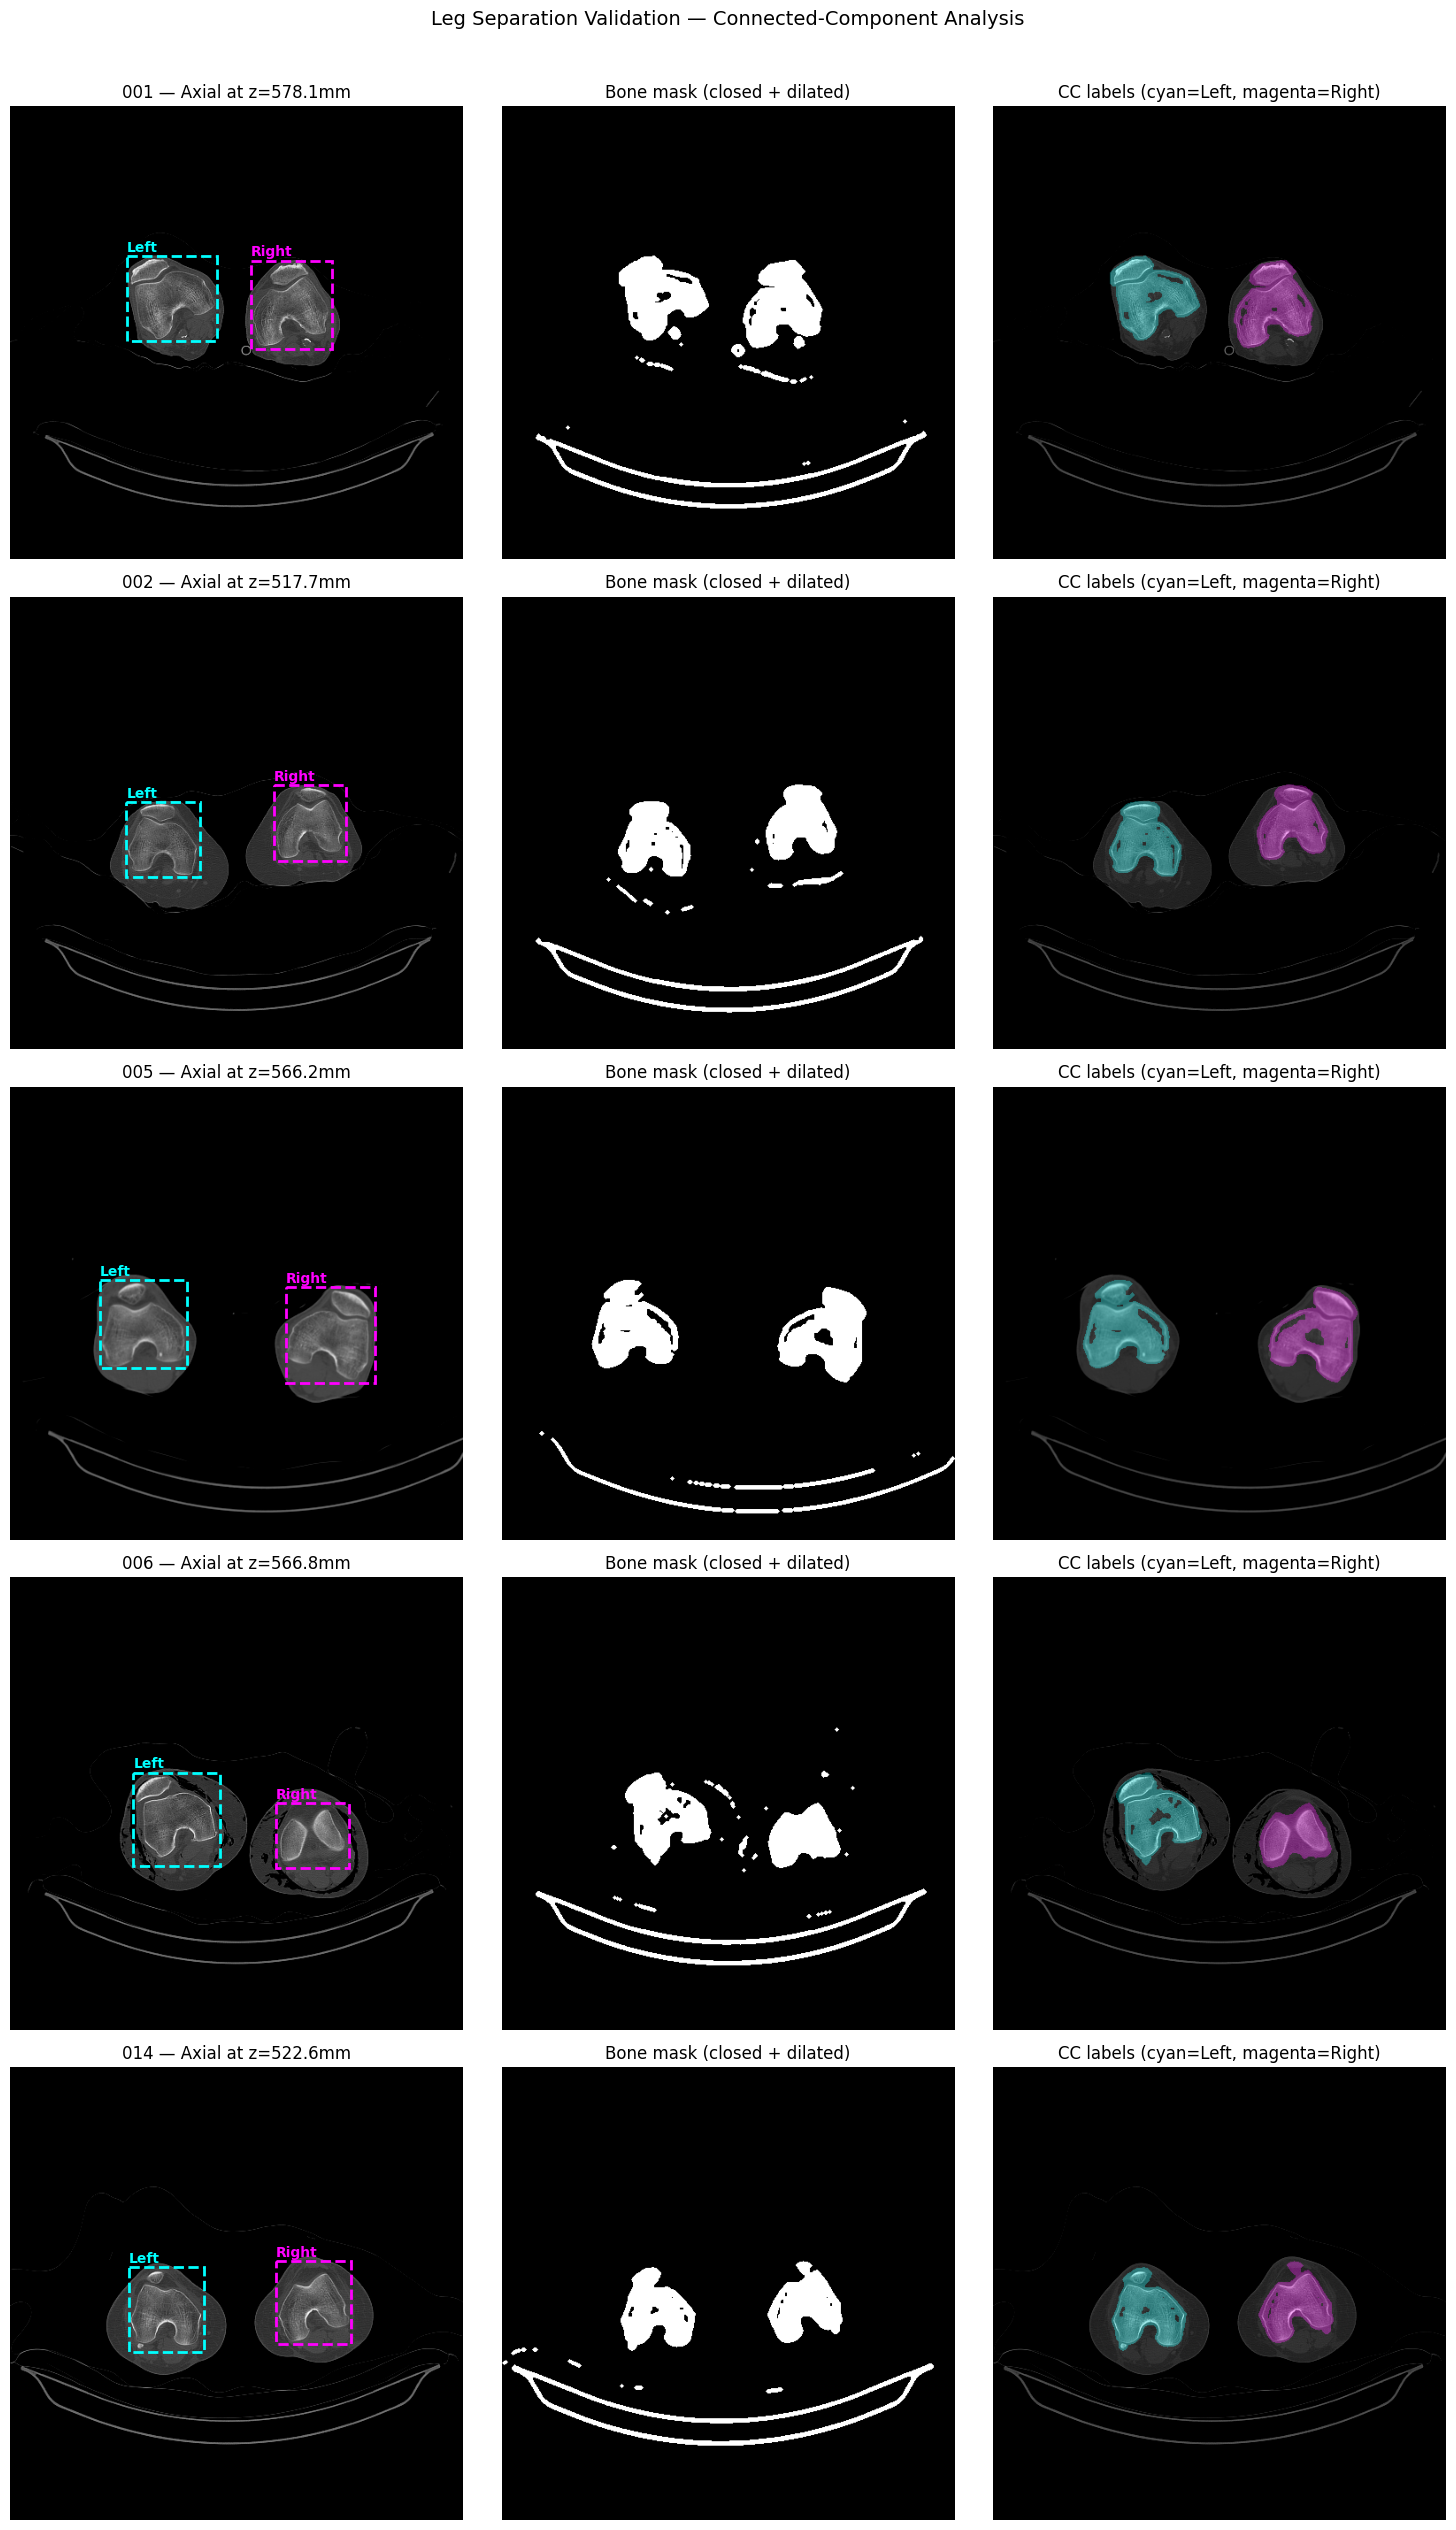

In [5]:
n_subjects = len(knee_results)
fig, axes = plt.subplots(n_subjects, 3, figsize=(15, 5 * n_subjects))
if n_subjects == 1:
    axes = axes[np.newaxis, :]

for i, result in enumerate(knee_results):
    arr = result["arr"]
    ks = result["knee_slice"]
    legs = result["legs"]
    labeled = result["cc_labeled"]
    bone_closed = result["cc_bone_closed"]

    # Panel 1: Raw axial slice at knee center
    axes[i, 0].imshow(arr[ks], cmap="gray", vmin=-500, vmax=1500)
    for leg in legs:
        color = "cyan" if leg["side"] == "Left" else "magenta"
        rect = plt.Rectangle(
            (leg["x_min"], leg["y_min"]),
            leg["x_max"] - leg["x_min"],
            leg["y_max"] - leg["y_min"],
            linewidth=2, edgecolor=color, facecolor="none", linestyle="--",
        )
        axes[i, 0].add_patch(rect)
        axes[i, 0].text(leg["x_min"], leg["y_min"] - 5, leg["side"],
                        color=color, fontsize=10, fontweight="bold")
    axes[i, 0].set_title(f"{result['subject_id']} — Axial at z={result['knee_z_mm']}mm")
    axes[i, 0].axis("off")

    # Panel 2: Bone mask after morphological closing
    axes[i, 1].imshow(bone_closed, cmap="gray")
    axes[i, 1].set_title("Bone mask (closed + dilated)")
    axes[i, 1].axis("off")

    # Panel 3: CC labels overlaid
    cc_display = np.zeros((*labeled.shape, 3), dtype=np.float32)
    for leg in legs:
        mask = labeled == leg["label"]
        if leg["side"] == "Left":
            cc_display[mask] = [0, 1, 1]  # cyan
        else:
            cc_display[mask] = [1, 0, 1]  # magenta
    axes[i, 2].imshow(arr[ks], cmap="gray", vmin=-500, vmax=1500)
    axes[i, 2].imshow(cc_display, alpha=0.3)
    axes[i, 2].set_title("CC labels (cyan=Left, magenta=Right)")
    axes[i, 2].axis("off")

plt.suptitle("Leg Separation Validation — Connected-Component Analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 6 — Crop Knee Volumes & Save as NIfTI

For each subject and each leg:
1. Z-crop: ±100mm around knee center
2. X/Y-crop: use the CC bounding box for that leg (with padding)
3. Save the cropped volume as NIfTI, preserving spatial metadata

Output naming: `VSD_{subject_id}_{Left|Right}.nii.gz`

In [6]:
XY_PAD_PIXELS = 15  # padding around leg bounding box in x/y


def crop_knee_volume(img, arr, knee_slice, leg, crop_margin_mm=KNEE_CROP_MARGIN_MM,
                     xy_pad=XY_PAD_PIXELS):
    """
    Crop a single knee volume from a bilateral lower-limb scan.

    Returns the cropped SimpleITK image with correct spatial metadata.
    """
    spacing = img.GetSpacing()  # (x, y, z)

    # Z-crop: ±margin around knee center
    margin_slices = int(crop_margin_mm / spacing[2])
    z_min = max(0, knee_slice - margin_slices)
    z_max = min(arr.shape[0], knee_slice + margin_slices)

    # X/Y-crop: from CC bounding box with padding
    x_min = max(0, leg["x_min"] - xy_pad)
    x_max = min(arr.shape[2], leg["x_max"] + xy_pad)
    y_min = max(0, leg["y_min"] - xy_pad)
    y_max = min(arr.shape[1], leg["y_max"] + xy_pad)

    # Crop the array (z, y, x)
    cropped_arr = arr[z_min:z_max, y_min:y_max, x_min:x_max].copy()

    # Create SimpleITK image with correct spatial metadata
    cropped_img = sitk.GetImageFromArray(cropped_arr)
    cropped_img.SetSpacing(spacing)

    # Compute the new origin based on the crop offset
    origin = img.GetOrigin()
    direction = img.GetDirection()
    new_origin = (
        origin[0] + x_min * spacing[0] * direction[0] + y_min * spacing[1] * direction[1],
        origin[1] + x_min * spacing[0] * direction[3] + y_min * spacing[1] * direction[4],
        origin[2] + z_min * spacing[2] * direction[8],
    )
    cropped_img.SetOrigin(new_origin)
    cropped_img.SetDirection(direction)

    crop_info = {
        "z_min": z_min, "z_max": z_max,
        "y_min": y_min, "y_max": y_max,
        "x_min": x_min, "x_max": x_max,
        "cropped_shape": cropped_arr.shape,
        "phys_z_mm": round((z_max - z_min) * spacing[2], 1),
    }

    return cropped_img, crop_info


# Crop and save all knee volumes
all_crop_metadata = []
saved_count = 0

print(f"Cropping knee volumes to {OUTPUT_DIR}...\n")

for result in knee_results:
    sid = result["subject_id"]
    img = result["img"]
    arr = result["arr"]
    knee_slice = result["knee_slice"]

    for leg in result["legs"]:
        side = leg["side"]
        out_name = f"VSD_{sid}_{side}.nii.gz"
        out_path = OUTPUT_DIR / out_name

        try:
            cropped_img, crop_info = crop_knee_volume(img, arr, knee_slice, leg)

            sitk.WriteImage(cropped_img, str(out_path))

            meta = {
                "subject_id": sid,
                "side": side,
                "output_file": out_name,
                "output_path": str(out_path),
                "knee_slice": knee_slice,
                "knee_z_mm": result["knee_z_mm"],
                **crop_info,
            }
            all_crop_metadata.append(meta)
            saved_count += 1

            print(f"  ✅ {out_name}: shape={crop_info['cropped_shape']}, "
                  f"z-extent={crop_info['phys_z_mm']}mm")

        except Exception as e:
            print(f"  ❌ {out_name}: {e}")

# Save metadata CSV
df_crop_meta = pd.DataFrame(all_crop_metadata)
meta_path = OUTPUT_DIR / "vsd_knee_crop_metadata.csv"
df_crop_meta.to_csv(meta_path, index=False)

print(f"\n{'='*60}")
print(f"Done. {saved_count} knee volumes saved.")
print(f"Metadata: {meta_path}")

Cropping knee volumes to c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy...

  ✅ VSD_001_Left.nii.gz: shape=(332, 126, 132), z-extent=199.1mm
  ✅ VSD_001_Right.nii.gz: shape=(332, 130, 121), z-extent=199.1mm
  ✅ VSD_002_Left.nii.gz: shape=(332, 115, 113), z-extent=199.1mm
  ✅ VSD_002_Right.nii.gz: shape=(332, 116, 111), z-extent=199.1mm
  ✅ VSD_005_Left.nii.gz: shape=(332, 130, 129), z-extent=199.1mm
  ✅ VSD_005_Right.nii.gz: shape=(332, 138, 131), z-extent=199.1mm
  ✅ VSD_006_Left.nii.gz: shape=(284, 135, 128), z-extent=198.7mm
  ✅ VSD_006_Right.nii.gz: shape=(284, 104, 113), z-extent=198.7mm
  ✅ VSD_014_Left.nii.gz: shape=(332, 125, 115), z-extent=199.2mm
  ✅ VSD_014_Right.nii.gz: shape=(332, 123, 115), z-extent=199.2mm

Done. 10 knee volumes saved.
Metadata: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy\vsd_knee_crop_metadata.csv


## Cell 7 — Post-Crop Validation

Verify each saved knee volume by checking shape, HU range, and visualizing 3-plane views. This is the most important cell — inspect these outputs carefully before proceeding to preprocessing.

Validating 10 saved knee volumes...

  ✅ VSD_001_Left.nii.gz: (332, 126, 132), HU=[-1024, 2307]
  ✅ VSD_001_Right.nii.gz: (332, 130, 121), HU=[-1024, 3057]
  ✅ VSD_002_Left.nii.gz: (332, 115, 113), HU=[-1024, 2336]
  ✅ VSD_002_Right.nii.gz: (332, 116, 111), HU=[-1024, 3071]
  ✅ VSD_005_Left.nii.gz: (332, 130, 129), HU=[-1024, 1703]
  ✅ VSD_005_Right.nii.gz: (332, 138, 131), HU=[-1024, 1752]
  ✅ VSD_006_Left.nii.gz: (284, 135, 128), HU=[-1024, 2258]
  ✅ VSD_006_Right.nii.gz: (284, 104, 113), HU=[-1024, 2138]
  ✅ VSD_014_Left.nii.gz: (332, 125, 115), HU=[-1024, 2167]
  ✅ VSD_014_Right.nii.gz: (332, 123, 115), HU=[-1024, 2086]


,file,"shape (z,y,x)","spacing (x,y,z)",HU_min,HU_max,phys_z_mm,phys_x_mm,phys_y_mm
0,VSD_001_Left.nii.gz,"(332, 126, 132)","(0.9766, 0.9766, 0.5997)",-1024.0,2307.0,199.1,128.9,123.0
1,VSD_001_Right.nii.gz,"(332, 130, 121)","(0.9766, 0.9766, 0.5997)",-1024.0,3057.0,199.1,118.2,127.0
2,VSD_002_Left.nii.gz,"(332, 115, 113)","(0.9766, 0.9766, 0.5998)",-1024.0,2336.0,199.1,110.4,112.3
3,VSD_002_Right.nii.gz,"(332, 116, 111)","(0.9766, 0.9766, 0.5998)",-1024.0,3071.0,199.1,108.4,113.3
4,VSD_005_Left.nii.gz,"(332, 130, 129)","(0.8594, 0.8594, 0.5998)",-1024.0,1703.0,199.1,110.9,111.7
5,VSD_005_Right.nii.gz,"(332, 138, 131)","(0.8594, 0.8594, 0.5998)",-1024.0,1752.0,199.1,112.6,118.6
6,VSD_006_Left.nii.gz,"(284, 135, 128)","(0.9766, 0.9766, 0.6998)",-1024.0,2258.0,198.7,125.0,131.8
7,VSD_006_Right.nii.gz,"(284, 104, 113)","(0.9766, 0.9766, 0.6998)",-1024.0,2138.0,198.7,110.4,101.6
8,VSD_014_Left.nii.gz,"(332, 125, 115)","(0.9043, 0.9043, 0.5999)",-1024.0,2167.0,199.2,104.0,113.0
9,VSD_014_Right.nii.gz,"(332, 123, 115)","(0.9043, 0.9043, 0.5999)",-1024.0,2086.0,199.2,104.0,111.2


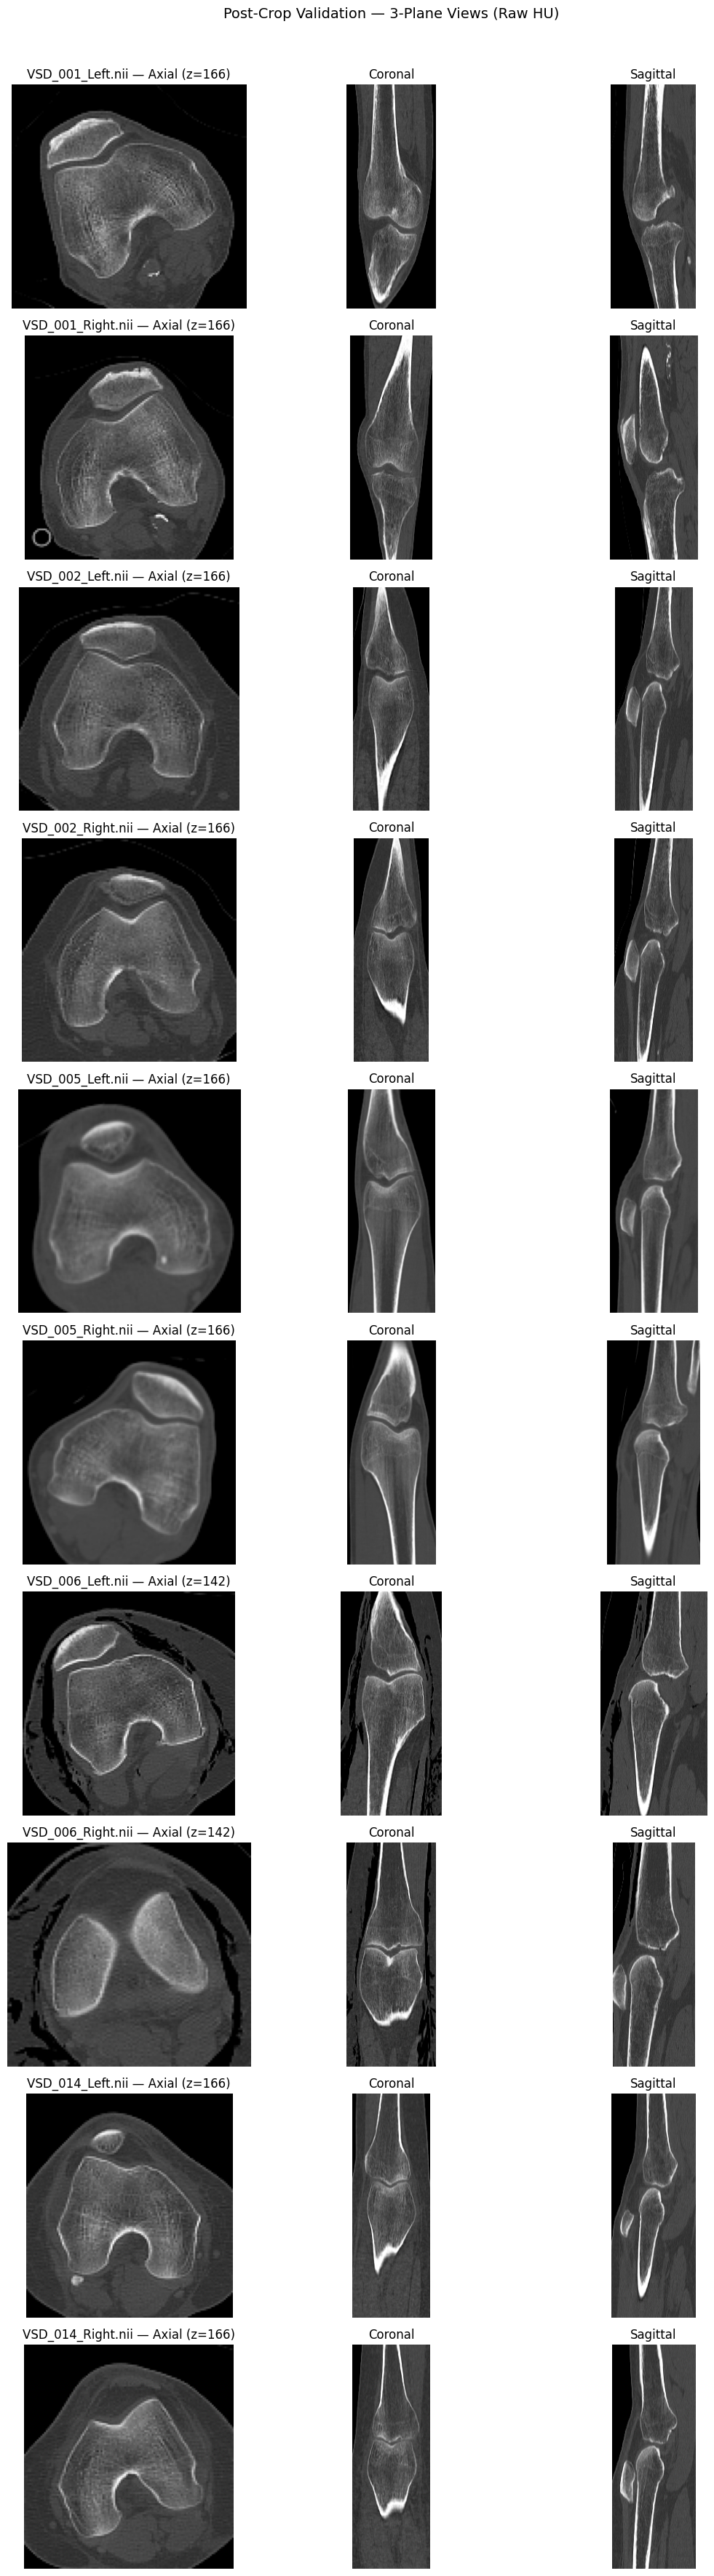

In [7]:
saved_files = sorted(OUTPUT_DIR.glob("VSD_*.nii.gz"))
n_files = len(saved_files)

print(f"Validating {n_files} saved knee volumes...\n")

# Summary table
val_records = []
for fpath in saved_files:
    vol = sitk.ReadImage(str(fpath))
    arr = sitk.GetArrayFromImage(vol)
    sp = vol.GetSpacing()

    val_records.append({
        "file": fpath.name,
        "shape (z,y,x)": arr.shape,
        "spacing (x,y,z)": tuple(round(s, 4) for s in sp),
        "HU_min": round(float(arr.min()), 1),
        "HU_max": round(float(arr.max()), 1),
        "phys_z_mm": round(arr.shape[0] * sp[2], 1),
        "phys_x_mm": round(arr.shape[2] * sp[0], 1),
        "phys_y_mm": round(arr.shape[1] * sp[1], 1),
    })
    print(f"  ✅ {fpath.name}: {arr.shape}, HU=[{arr.min():.0f}, {arr.max():.0f}]")

display(pd.DataFrame(val_records))

# 3-plane visualization for each volume
fig, axes = plt.subplots(n_files, 3, figsize=(12, 3.5 * n_files))
if n_files == 1:
    axes = axes[np.newaxis, :]

for i, fpath in enumerate(saved_files):
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(fpath)))
    mid = [s // 2 for s in arr.shape]

    axes[i, 0].imshow(arr[mid[0], :, :], cmap="gray", vmin=-500, vmax=1500)
    axes[i, 0].set_title(f"{fpath.stem} — Axial (z={mid[0]})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(arr[:, mid[1], :], cmap="gray", vmin=-500, vmax=1500)
    axes[i, 1].set_title("Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(arr[:, :, mid[2]], cmap="gray", vmin=-500, vmax=1500)
    axes[i, 2].set_title("Sagittal")
    axes[i, 2].axis("off")

plt.suptitle("Post-Crop Validation — 3-Plane Views (Raw HU)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Pipeline Summary & Next Steps

### Summary
- **Input**: 6 VSD lower-limb DICOM subjects (1 excluded: 010)
- **Output**: 10 individual knee volumes in `data/raw/healthy/` (5 subjects × 2 legs)
- **Pipeline**: Discover → Identify knee (bone profile) → Separate legs (CC analysis) → Crop ±100mm → Save NIfTI

### Next Steps
1. **Review the 3-plane views above** — verify each cropped volume contains the full knee joint (distal femur, proximal tibia/fibula, patella)
2. If crops look correct, proceed to the **unified preprocessing notebook** (`predrr_preprocessing.ipynb`) which will standardize both healthy and fractured volumes
3. Future VSD subjects can be added to `data/raw/VSD_Dataset/` and re-processed through this notebook

> **Note**: These cropped volumes are raw HU values. They still need to go through the preprocessing pipeline (resample to 0.5mm isotropic, orient to LAS, bone windowing, ROI crop, resize to target) before DRR generation.